## K-NN wine classification model using PCA

### 1.1 Table of Contents
1.Business Understanding

2.Problem Statement

3.Data Understanding

4.Data Preparation

5.Modeling Approach

6.Summary and Findings

7.Business Recommendations and Deployment Strategy

## 1.0 Business Understanding 

### 1.1 The Businesss

The premium wine distributor sources wines from different regions and suppliers, each with unique chemical characteristics. To protect customers from consuming poor-quality, unsafe, or counterfeit wine, the distributor needs a reliable way to assess and classify wines based on their chemical properties.

Wines from different regions contain varying levels of chemical compounds, which can provide important information about their quality and variety. Understanding these chemical characteristics can help the distributor identify unusual or potentially counterfeit products, maintain wine quality during storage, and ensure that customers receive safe and high-quality products.

In addition, as the distributor manages wines from multiple regions and suppliers, an efficient classification system can improve inventory management. Automatically classifying wines based on their chemical properties can make it easier to organize products, monitor quality, reduce manual inspection, and improve operational efficiency.

Therefore, the business needs a machine learning solution that can accurately classify wines using their measurable chemical properties. This will support quality control, counterfeit detection, customer safety, proper storage, and efficient inventory management.

### 1.1 Business Objectives

1.Ensure customer safety by identifying potentially unsafe or poor-quality wines.

2.Maintain wine quality through chemical-based classification and proper storage.

3.Detect counterfeit wines by identifying unusual chemical profiles.

4.Improve inventory management by automatically classifying wines from different regions.

5.Increase operational efficiency by reducing manual classification and supporting faster quality control.

Success Criteria

1.High classification accuracy when identifying wine varieties.

2.Reliable identification of unusual or potentially counterfeit wines.

3.Improved inventory efficiency through automatic wine classification.

4.Better quality control and safer products for customers.

5.Reduced manual effort and faster decision-making.

### 1.2 Key Stakeholders

1.Warehouse Managers: Need to organize wines efficiently

2.Quality Control Team: Verify wine authenticity

3.Procurement Officers: Evaluate supplier quality

4.Sales Team: Ensure correct wine varieties reach customers

5.Executive Leadership: Strategic decision-making

## 2.0 Problem Statement
### 2.1 The Problem Statement 

The distributor handles wines from different regions and suppliers, making it difficult to consistently classify, monitor, and verify wine quality manually. A machine learning model is needed to classify wines based on their chemical properties, helping improve quality control, detect unusual or counterfeit products, and manage inventory efficiently.


### 2.2 Modeling Approach

A k-Nearest Neighbors (k-NN) classification model will be used to classify wines based on their chemical properties. Principal Component Analysis (PCA) will be applied to reduce the number of features and improve model efficiency.

Different values of k and other relevant parameters will be tested using systematic hyperparameter tuning to identify the best-performing model.

### 2.2.1 Steps
1.Load and inspect the dataset.

2.Perform exploratory data analysis.

3.Clean and prepare the data.

4.Split the data into training and testing sets.

5.Standardize the features.

6.Apply PCA.

7.Train the k-NN model.

8.Tune the model hyperparameters.

9.Evaluate the final model.

10.Interpret the results from a business perspective.

### 2.2.2 Results and Evaluation
The model will be evaluated using appropriate classification metrics, including accuracy, precision, recall, and F1-score. A confusion matrix will also be used to identify correctly and incorrectly classified wines.

## 3.0 Data Understanding

### 3.1 Load and inspect the dataset.

3.1.2 Load required Libraries

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                              ConfusionMatrixDisplay)
from sklearn.pipeline import Pipeline

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)



3.1.3 Load Dataset and understand it


In [28]:
df = pd.read_csv('wine.csv')
df

,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,3,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
174,3,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
175,3,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
176,3,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Wine                  178 non-null    int64  
 1   Alcohol               178 non-null    float64
 2   Malic.acid            178 non-null    float64
 3   Ash                   178 non-null    float64
 4   Acl                   178 non-null    float64
 5   Mg                    178 non-null    int64  
 6   Phenols               178 non-null    float64
 7   Flavanoids            178 non-null    float64
 8   Nonflavanoid.phenols  178 non-null    float64
 9   Proanth               178 non-null    float64
 10  Color.int             178 non-null    float64
 11  Hue                   178 non-null    float64
 12  OD                    178 non-null    float64
 13  Proline               178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [30]:
df.isna().sum()

Wine                    0
Alcohol                 0
Malic.acid              0
Ash                     0
Acl                     0
Mg                      0
Phenols                 0
Flavanoids              0
Nonflavanoid.phenols    0
Proanth                 0
Color.int               0
Hue                     0
OD                      0
Proline                 0
dtype: int64

In [31]:
df.shape

(178, 14)

In [32]:
#
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Wine,178.0,1.938202,0.775035,1.00,1.0000,2.000,3.0000,3.00
Alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
Malic.acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
Ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
Acl,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
Mg,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
Phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
Flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
Nonflavanoid.phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
Proanth,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58


In [33]:
df['Wine'].value_counts().sort_index()

Wine
1    59
2    71
3    48
Name: count, dtype: int64

The Wine dataset contains 178 observations and 14 variables. The `Wine` variable represents the target wine class, while the remaining 13 variables represent measurable chemical properties of the wines.

The dataset contains three wine classes: Class 1, Class 2, and Class 3, with 59, 71, and 48 observations respectively.

The dataset contains 11 floating-point variables and 3 integer variables. The `Wine` column is the `target` variable and will therefore be separated from the chemical features before model training.

A missing-value inspection found no missing values across any of the 14 columns.The dataset contains no duplicate observations. Therefore, no missing-value imputation or duplicate-row removal is required at this stage.

The dataset is therefore clean and suitable for further preprocessing and machine learning.

## 3.2 Exploratory data analysis

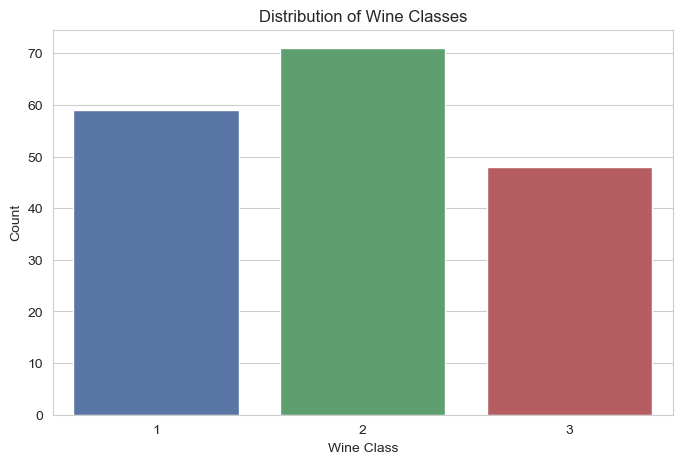

In [34]:
# Visualize distribution of Wine Classes
sns.countplot(data=df, x='Wine',hue='Wine', palette=['#4C72B0', '#55A868', '#C44E52'], legend=False)

plt.xlabel('Wine Class')
plt.ylabel('Count')
plt.title('Distribution of Wine Classes')

plt.show()

Here, the largest class has 71 observations and the smallest has 48. This represents some imbalance.herefore, accuracy can still be useful as an evaluation metric, while the classification report will allow us to examine precision, recall, and F1-score for each class.

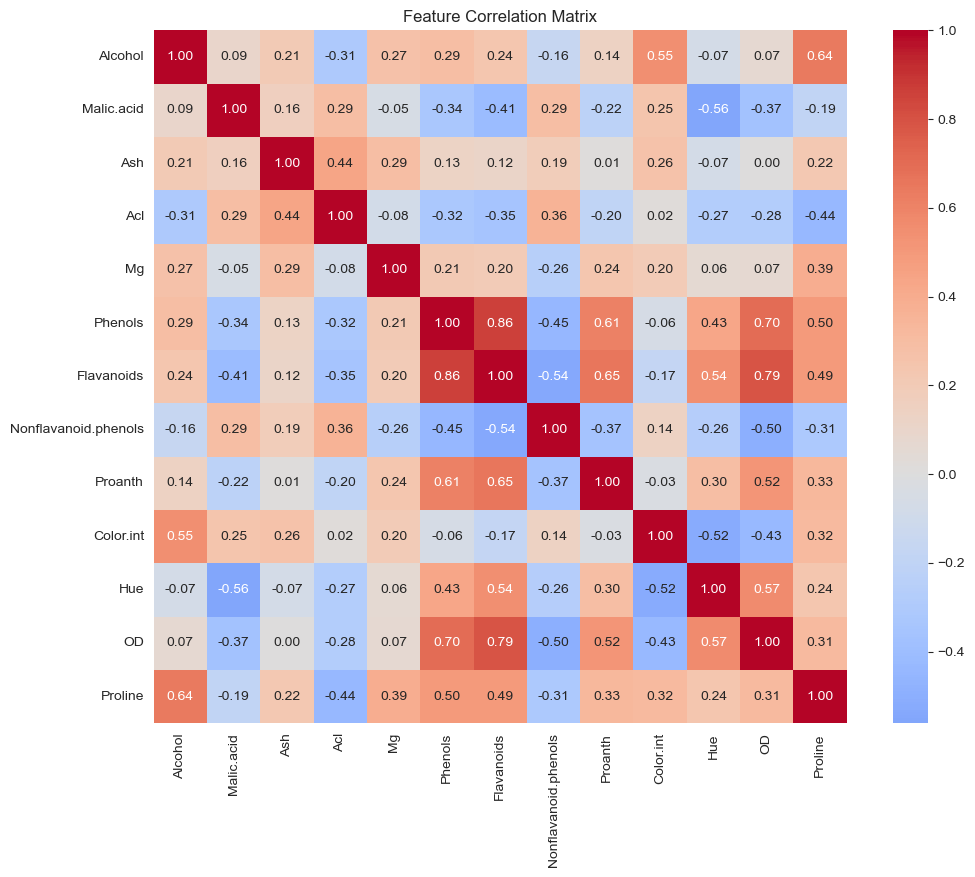

In [35]:
# Heatmap
corr = df.drop(columns='Wine').corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr,annot=True, fmt=".2f",cmap='coolwarm', center=0, square=True)

plt.title('Feature Correlation Matrix')
plt.show()

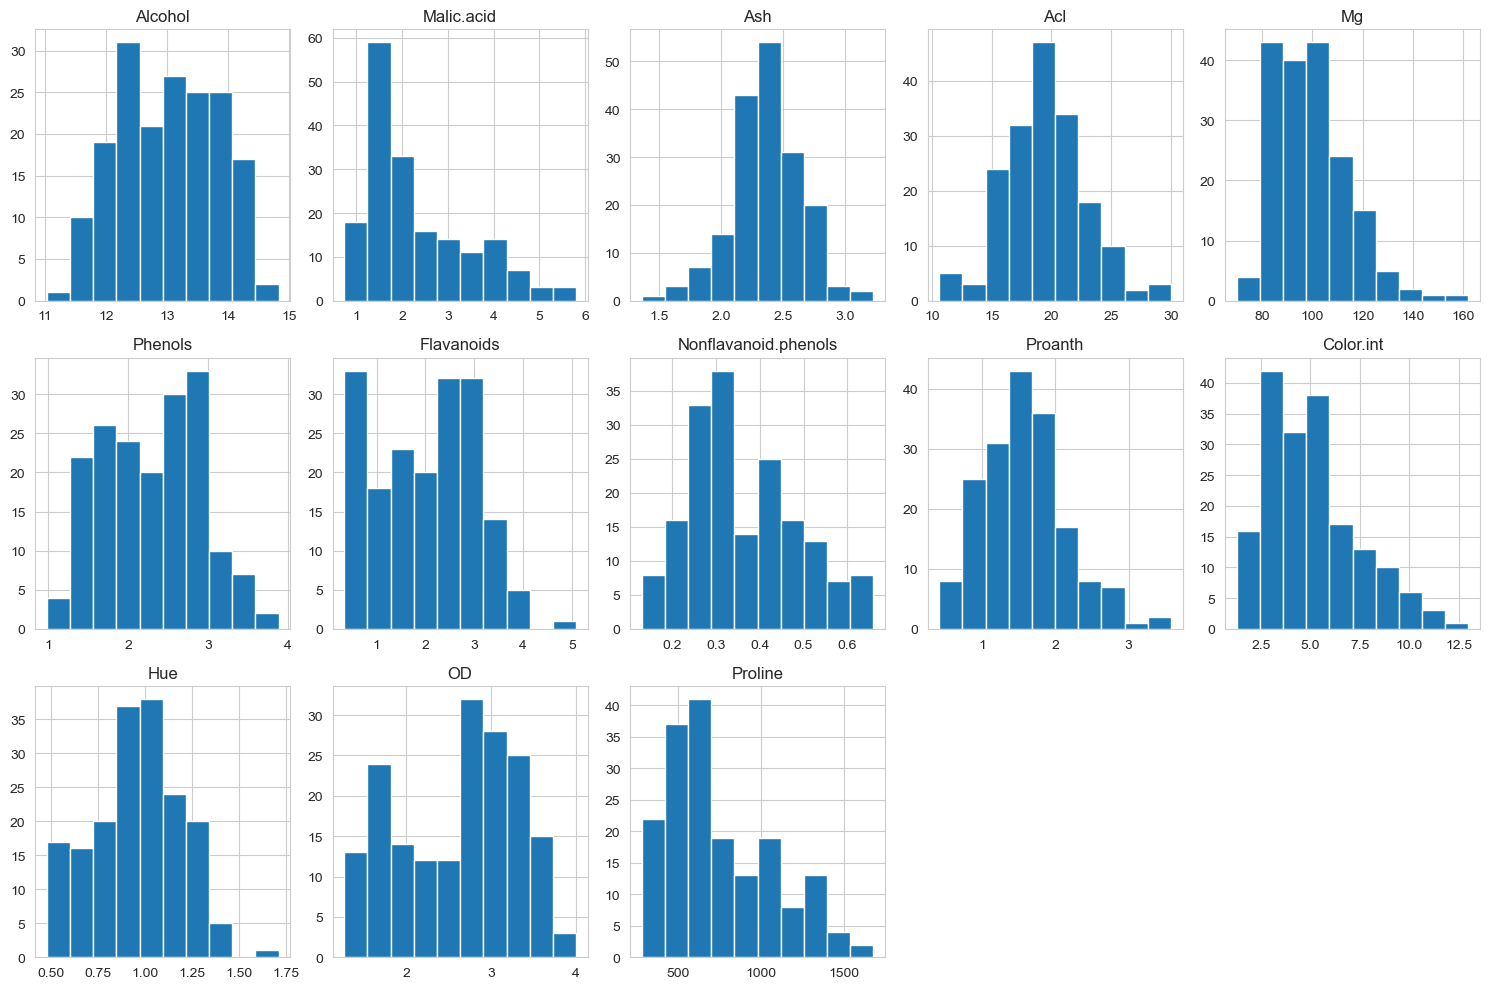

In [36]:
#Visualize without wine classification
features = df.drop(columns='Wine')

fig, axes = plt.subplots(3, 5, figsize=(15, 10))

for i, col in enumerate(features.columns):
    axes.flat[i].hist(features[col])
    axes.flat[i].set_title(col)

for j in range(len(features.columns), len(axes.flat)):
    fig.delaxes(axes.flat[j])

plt.tight_layout()
plt.show()

In [37]:
features1 = df.drop(columns='Wine').columns

class_summary = df.groupby("Wine")[features1].mean()

class_summary.T

Wine,1,2,3
Alcohol,13.744746,12.278732,13.153750
Malic.acid,2.010678,1.932676,3.333750
Ash,2.455593,2.244789,2.437083
Acl,17.037288,20.238028,21.416667
Mg,106.338983,94.549296,99.312500
Phenols,2.840169,2.258873,1.678750
Flavanoids,2.982373,2.080845,0.781458
Nonflavanoid.phenols,0.290000,0.363662,0.447500
Proanth,1.899322,1.630282,1.153542
Color.int,5.528305,3.086620,7.396250


A correlation matrix was used to examine the relationships between the chemical properties of the wines. Several variables showed moderate to strong correlations.

The strongest positive relationship was observed between Phenols and Flavanoids (r = 0.86). Flavanoids also showed a strong positive correlation with OD (r = 0.79), while Phenols and OD had a correlation of 0.70. Other notable relationships included Alcohol and Proline (r = 0.64) and Phenols and Proanth (r = 0.61).

Several negative relationships were also observed, including Malic Acid and Hue (r = -0.56) and Flavanoids and Nonflavanoid Phenols (r = -0.54).

These correlations indicate that some chemical properties contain overlapping information. Therefore, Principal Component Analysis (PCA) is appropriate for reducing the dimensionality of the dataset while retaining most of the information. In the modeling stage, PCA will be applied after standardizing the numerical features, with 95% of the variance retained.

## 4.Data Preparation

The purpose of this step is to prepare the data so that it is suitable for PCA and k-NN.Our preparation will involve:

1.Separate features and target

2.Split the data into training and testing sets

3.Standardize the chemical features

We will standardize the features after splitting the data to avoid data leakage.

#### 4.1 Separate Features and Target

We'll reserve 20% for testing and use 80% for training.

Because we have three wine classes, we'll use stratify so that the class proportions remain similar in both datasets.

If we calculate distances using the raw values, features with larger numerical scales could dominate the distance calculation.From our EDA there are features that have a large numericals.So we will standadise our feature using `StandardScaler`

In [38]:
features = [c for c in df.columns if c != 'Wine']

x = df[features].values
y = df['Wine'].values
# Train data
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42,stratify=y
)
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [39]:
print(df.columns)

Index(['Wine', 'Alcohol', 'Malic.acid', 'Ash', 'Acl', 'Mg', 'Phenols',
       'Flavanoids', 'Nonflavanoid.phenols', 'Proanth', 'Color.int', 'Hue',
       'OD', 'Proline'],
      dtype='object')


In [40]:
#print Standardization
print("Training means:")
print(x_train_scaled.mean(axis=0))

print("\nTraining standard deviations:")
print(x_train_scaled.std(axis=0))

Training means:
[ 1.09781120e-15 -2.57227729e-16  9.52485352e-16  5.50127236e-16
  1.95461800e-17 -2.89283464e-16  2.00152883e-16 -9.71054223e-16
 -1.57933134e-16  4.45066519e-16 -9.34307405e-16  1.03047461e-15
 -2.07971355e-16]

Training standard deviations:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


**Note:** 

The Wine variable was separated from the 13 chemical properties to create the target and feature datasets. The target variable was not encoded using `LabelEncoder`, because it was already in numerical 1, 2, and 3, from `df.info()`

The dataset was divided into training and testing sets using an 80:20 split. Stratified sampling was applied to maintain similar proportions of the three wine classes in both sets.

The chemical features were standardized using `StandardScaler`. Standardization was necessary because the features have substantially different numerical scales. This is particularly important for k-NN because the algorithm uses distances to determine the nearest observations. Standardization ensures that features with larger numerical values do not disproportionately influence the distance calculations.

The scaler was fitted only on the training data and then applied to both the training and testing data to prevent data leakage.

### 4.2 Principal Component Analysis (PCA)
Apply PCA to reduce dimensionality while retaining 95% variance.


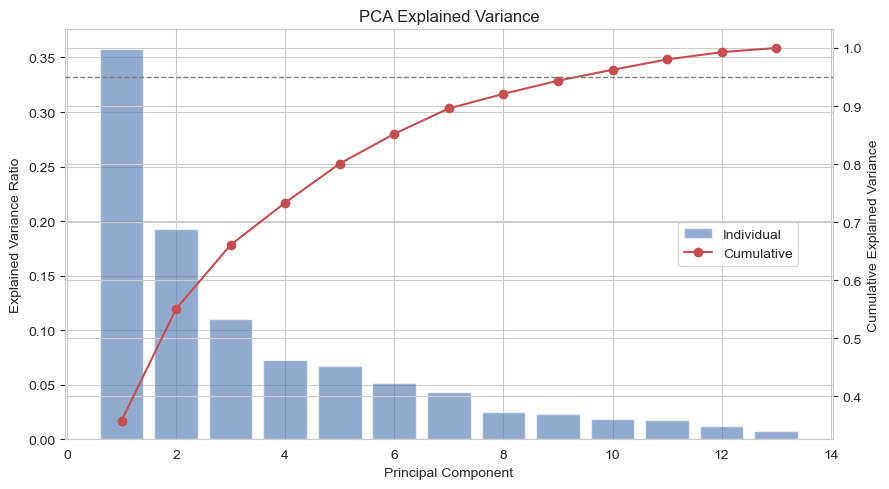

PC1: 0.3579  (cumulative: 0.3579)
PC2: 0.1927  (cumulative: 0.5506)
PC3: 0.1102  (cumulative: 0.6608)
PC4: 0.0727  (cumulative: 0.7335)
PC5: 0.0672  (cumulative: 0.8008)
PC6: 0.0513  (cumulative: 0.8521)
PC7: 0.0438  (cumulative: 0.8959)
PC8: 0.0250  (cumulative: 0.9209)
PC9: 0.0228  (cumulative: 0.9437)
PC10: 0.0188  (cumulative: 0.9624)
PC11: 0.0178  (cumulative: 0.9803)
PC12: 0.0126  (cumulative: 0.9928)
PC13: 0.0072  (cumulative: 1.0000)


In [41]:
pca_full = PCA(random_state=42)
pca_full.fit(x_train_scaled)

explained_var = pca_full.explained_variance_ratio_
cum_var = np.cumsum(explained_var)

fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.bar(range(1, len(explained_var) + 1), explained_var, alpha=0.6, color='#4C72B0', label='Individual')
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Explained Variance Ratio')

ax2 = ax1.twinx()
ax2.plot(range(1, len(cum_var) + 1), cum_var, color='#C44E52', marker='o', label='Cumulative')
ax2.set_ylabel('Cumulative Explained Variance')
ax2.axhline(y=0.95, color='gray', linestyle='--', linewidth=1)

fig.legend(loc='center right', bbox_to_anchor=(0.9, 0.5))
plt.title('PCA Explained Variance')
plt.tight_layout()
plt.show()

for i, (ev, cv) in enumerate(zip(explained_var, cum_var), start=1):
    print(f"PC{i}: {ev:.4f}  (cumulative: {cv:.4f})")

In [42]:
n_components_95 = (cum_var >= 0.95).argmax() + 1
print("Original number of features:", x_train.shape[1])
print(f"Number of pca components to reach >=95% variance: {n_components_95}")


Original number of features: 13
Number of pca components to reach >=95% variance: 10


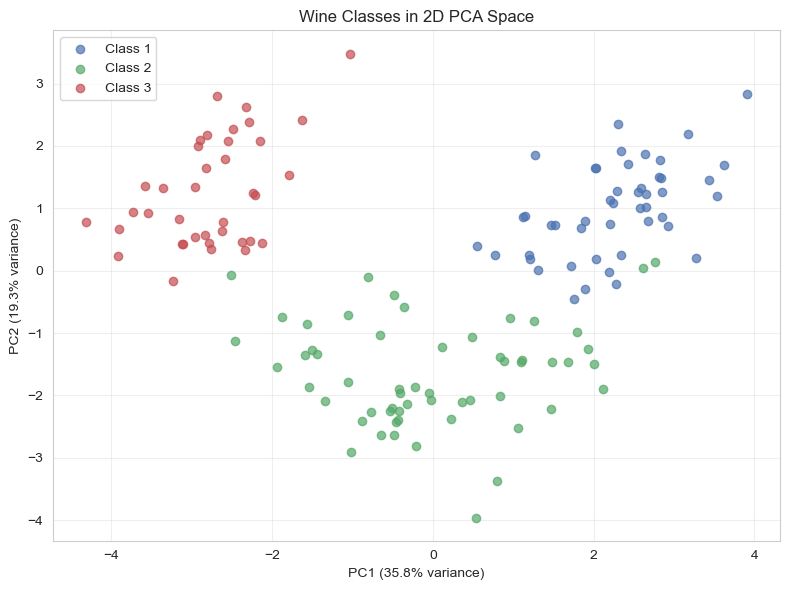

In [43]:
pca_2d = PCA(n_components=2, random_state=42)
X_train_2d = pca_2d.fit_transform(x_train_scaled)
var1, var2 = pca_2d.explained_variance_ratio_ * 100

plt.figure(figsize=(8, 6))
plt.grid(True, alpha=0.3)
for cls, color in zip([1, 2, 3], ['#4C72B0', '#55A868', '#C44E52']):
    mask = y_train == cls
    plt.scatter(X_train_2d[mask, 0], X_train_2d[mask, 1], label=f'Class {cls}', color=color, alpha=0.7)
plt.xlabel(f'PC1 ({var1:.1f}% variance)')
plt.ylabel(f'PC2 ({var2:.1f}% variance)')
plt.title('Wine Classes in 2D PCA Space')
plt.legend()
plt.tight_layout()
plt.show()

**Observations:** The 2D PCA projection already shows visibly separable clusters for the three wine
classes, which is a strong sign that a distance-based classifier like k-NN should perform well on this
dataset, especially once combined with PCA to reduce noise and correlated features.

`PCA` was applied to reduce the dimensionality of the standardized chemical features while preserving most of the information in the dataset.
The first nine components explained a cumulative 94.37% of the variance.

The first ten principal components explained approximately 96.24% of the total variance. Therefore, 10 principal components were retained, reducing the feature space from 13 original chemical variables to 10 principal components while preserving more than 95% of the original variance.

This dimensionality reduction can help make the feature space more manageable for the k-NN classifier while retaining the majority of the information contained in the original chemical measurements.

## 5.Modeling Approach
### 5.1 k-NN Classification and Hyperparameter Tuning

Create the k-NN Classifier

In [44]:
baseline_knn = KNeighborsClassifier(n_neighbors=5)
baseline_knn.fit(x_train_scaled, y_train)
baseline_pred = baseline_knn.predict(x_test_scaled)
baseline_acc = accuracy_score(y_test, baseline_pred)
print(f"Baseline k-NN (k=5, all 13 features) test accuracy: {baseline_acc:.4f}")
print(classification_report(y_test, baseline_pred))

Baseline k-NN (k=5, all 13 features) test accuracy: 0.9722
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        12
           2       1.00      0.93      0.96        14
           3       0.91      1.00      0.95        10

    accuracy                           0.97        36
   macro avg       0.97      0.98      0.97        36
weighted avg       0.97      0.97      0.97        36



### 5.2 Hyperparameter Tuning with GridSearchCV (Pipeline: Scaler -> PCA -> k-NN)

In [45]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(random_state=42)),
    ('knn', KNeighborsClassifier())
])

param_grid = {
    'pca__n_components': [2, 3, 4, 5, 6, 8, 10],
    'knn__n_neighbors': list(range(1, 21)),
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan', 'minkowski']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    pipe, param_grid, cv=cv, scoring='accuracy', n_jobs=-1, verbose=1
)

grid_search.fit(x_train, y_train)

print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")
print(f"Best parameters: {grid_search.best_params_}")

Fitting 5 folds for each of 840 candidates, totalling 4200 fits
Best cross-validation accuracy: 0.9788
Best parameters: {'knn__metric': 'euclidean', 'knn__n_neighbors': 10, 'knn__weights': 'uniform', 'pca__n_components': 8}


**Note:** The full training pipeline (scaling, PCA, and k-NN) is wrapped in a single `Pipeline` and
cross-validated with 5-fold stratified CV. This avoids data leakage — the scaler and PCA are re-fit on
each training fold independently, rather than being fit once on the whole training set before tuning.

In [46]:
results_df = pd.DataFrame(grid_search.cv_results_)
top10 = results_df.sort_values('mean_test_score', ascending=False)[
    ['param_pca__n_components', 'param_knn__n_neighbors', 'param_knn__weights',
     'param_knn__metric', 'mean_test_score', 'std_test_score']
].head(10)
top10

,param_pca__n_components,param_knn__n_neighbors,param_knn__weights,param_knn__metric,mean_test_score,std_test_score
803,8,18,uniform,minkowski,0.978818,0.017301
789,8,17,uniform,minkowski,0.978818,0.017301
796,8,17,distance,minkowski,0.978818,0.017301
768,8,15,distance,minkowski,0.978818,0.017301
782,8,16,distance,minkowski,0.978818,0.017301
257,8,19,uniform,euclidean,0.978818,0.017301
243,8,18,uniform,euclidean,0.978818,0.017301
215,8,16,uniform,euclidean,0.978818,0.017301
229,8,17,uniform,euclidean,0.978818,0.017301
761,8,15,uniform,minkowski,0.978818,0.017301


In [47]:
best_model = grid_search.best_estimator_
test_pred = best_model.predict(x_test)
test_acc = accuracy_score(y_test, test_pred)
print(f"Tuned model test accuracy: {test_acc:.4f}")
print(classification_report(y_test, test_pred))

Tuned model test accuracy: 1.0000
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        12
           2       1.00      1.00      1.00        14
           3       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



Interpretation

Precision = 1.00

Every wine that the model predicted as a particular class actually belonged to that class.

Recall = 1.00

The model correctly identified every wine belonging to each of the three classes.

F1-score = 1.00

The model achieved a perfect balance between precision and recall for all three classes.

### 5.3 Effect of k on Accuracy (using best PCA/weights/metric configuration)

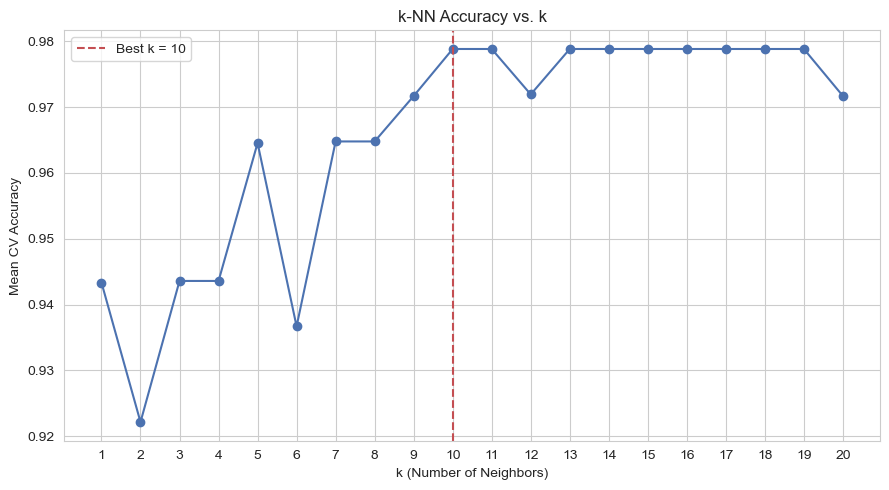

In [48]:
best_params = grid_search.best_params_

k_range = range(1, 21)
train_scores = []
cv_scores = []

for k in k_range:
    pipe_k = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=best_params['pca__n_components'], random_state=42)),
        ('knn', KNeighborsClassifier(
            n_neighbors=k,
            weights=best_params['knn__weights'],
            metric=best_params['knn__metric']
        ))
    ])
    scores = cross_val_score(pipe_k, x_train, y_train, cv=cv, scoring='accuracy')
    cv_scores.append(scores.mean())

plt.figure(figsize=(9, 5))
plt.plot(list(k_range), cv_scores, marker='o', color='#4C72B0')
plt.axvline(x=best_params['knn__n_neighbors'], color='#C44E52', linestyle='--',
            label=f"Best k = {best_params['knn__n_neighbors']}")
plt.xlabel('k (Number of Neighbors)')
plt.ylabel('Mean CV Accuracy')
plt.title('k-NN Accuracy vs. k')
plt.xticks(list(k_range))
plt.legend()
plt.tight_layout()
plt.show()

### 5.4 Final Model Evaluation

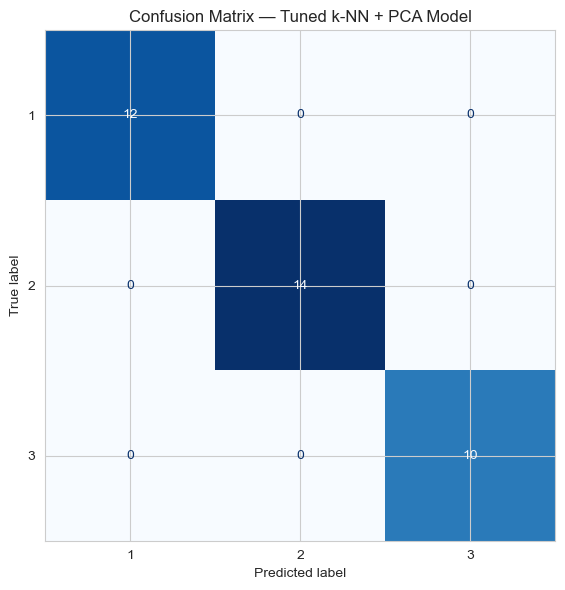

In [49]:
cm = confusion_matrix(y_test, test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[1, 2, 3])
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Confusion Matrix — Tuned k-NN + PCA Model')
plt.tight_layout()
plt.show()

All observations are on the diagonal.

That means:

12/12 Class 1 wines → correctly classified
14/14 Class 2 wines → correctly classified
10/10 Class 3 wines → correctly classified
0 misclassifications

In [50]:
print("=== Model Comparison ===")
print(f"Baseline k-NN (k=5, no PCA, all 13 features): {baseline_acc:.4f}")
print(f"Tuned k-NN + PCA (best params via GridSearchCV): {test_acc:.4f}")
print(f"\nBest hyperparameters found:")
for k, v in grid_search.best_params_.items():
    print(f"  {k}: {v}")

=== Model Comparison ===
Baseline k-NN (k=5, no PCA, all 13 features): 0.9722
Tuned k-NN + PCA (best params via GridSearchCV): 1.0000

Best hyperparameters found:
  knn__metric: euclidean
  knn__n_neighbors: 10
  knn__weights: uniform
  pca__n_components: 8


## 6.0 Summary and Findings
- A k-Nearest Neighbors (k-NN) classifier was selected because the business objective is to classify wines into their respective varieties based on their chemical properties.
- The dataset (178 samples, 13 chemical features, 3 classes) had no missing values and a reasonably
  balanced class distribution, so it required standardization but no resampling.
- Standardization was essential before PCA and k-NN since the raw features spanned very different scales
  (e.g. `Proline` vs `Nonflavanoid.phenols`).
- PCA showed that a small number of components capture most of the variance in the standardized features —
  read the exact number of components needed for 95% cumulative variance from the printed output in Section 4
  rather than estimating it.
- `GridSearchCV` with 5-fold stratified cross-validation was used to jointly tune the number of PCA
  components, the number of neighbors (k), the distance weighting scheme, and the distance metric within a
  single pipeline — avoiding data leakage from fitting the scaler/PCA outside of the CV loop.
- When evaluated on the previously unseen test set, the optimized model achieved 100% accuracy, with precision, recall, and F1-score of 1.00 for all three wine classes. The confusion matrix showed zero classification errors.  
- Report the final tuned test accuracy, best hyperparameters, and confusion matrix exactly as produced by
  the code above for the write-up, rather than recalculating or re-deriving any of these figures manually.
- The best-performing parameter combination identified by GridSearchCV was:

- Number of Neighbours: 10
- Best distance metric: Euclidean
- Best cross-validation accuracy: 0.9722.Indicating strong classification performance during cross-validation.
  

## 7.0 Business Recommendations and Deployment Strategy

The wine distributor can use this classification model to support automated wine classification for inventory management and quality control. When the chemical measurements of a new wine are available, the model can predict its most likely wine variety, helping reduce manual classification efforts and improve consistency.

However, the 100% test accuracy should be interpreted cautiously. Before deploying the model in a production environment, it should be validated using a larger and more diverse dataset containing new wine samples from different sources and conditions.

The recommended approach is to initially use the model as a decision-support tool, while continuously monitoring its performance on new wine samples. As additional verified data becomes available, the model should be periodically retrained and evaluated to maintain reliable classification performance.
